# Diagnóstico y mejora del modelo delay_30m — Distribution shift feb - mar 2026

El modelo LightGBM obtenía **MAE≈130s** en validación (oct-dic 2025) pero **MAE≈163s** en test (feb 2026).  
Este notebook analiza las causas del empeoramiento y evalúa estrategias de mitigación.

**Estructura:**
1. Carga de datos
2. Análisis del distribution shift
3. Análisis de alertas MTA
4. Impacto de la nevada (23-24 feb)
5. MAE real del modelo — versión completa (ene-dic 2025 + ene 2026)
6. Solución: ventana deslizante + pesos exponenciales (jul-dic 2025 + ene 2026)
7. Importancia de features vs drift
8. Evaluación en marzo 2026 — drift continuado y alertas rotas
9. Conclusiones

In [4]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score

from src.common.minio_client import download_df_parquet

ACCESS_KEY = os.environ['MINIO_ACCESS_KEY']
SECRET_KEY = os.environ['MINIO_SECRET_KEY']

DATA_TEMPLATE = 'grupo5/final/year={year}/month={month:02d}/dataset_final.parquet'
TARGET        = 'target_delay_30m'
FILTER_COL    = 'scheduled_time_to_end'
FILTER_VAL    = 1800

CAT_FEATURES  = ['route_id', 'direction', 'category', 'tipo_referente']
STOP_ID_COL   = 'stop_id'



## 1. Carga de datos

In [5]:
def load_months(year, months, label):
    dfs = []
    for month in months:
        path = DATA_TEMPLATE.format(year=year, month=month)
        try:
            df = download_df_parquet(ACCESS_KEY, SECRET_KEY, path)
            df = df[df['is_unscheduled'] == False]
            df = df.dropna(subset=[TARGET])
            df = df[df[FILTER_COL] >= FILTER_VAL]
            df['_periodo'] = label
            print(f'{year}-{month:02d}: {len(df):,} filas')
            dfs.append(df)
        except Exception as e:
            print(f' {year}-{month:02d}: {e}')
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print('Cargando validación (oct-dic 2025)...')
df_val = load_months(2025, range(10, 13), 'val (oct-dic 2025)')

print('\nCargando ene 2026...')
df_ene = load_months(2026, range(1, 2), 'ene 2026')

print('\nCargando test (feb 2026)...')
df_test = load_months(2026, range(2, 3), 'test (feb 2026)')

# Marzo 2026: SOLO para diagnóstico del fallo del pipeline de alertas MTA.
# No se usa en entrenamiento ni en evaluación del modelo.
print('\nCargando mar 2026 (solo diagnóstico alertas)...')
df_mar = load_months(2026, range(3, 4), 'mar 2026 [diagnóstico]')

print(f'\nResumen:')
print(f'  val (oct-dic 2025): {len(df_val):,} filas')
print(f'  ene 2026:           {len(df_ene):,} filas')
print(f'  test (feb 2026):    {len(df_test):,} filas')
print(f'  mar 2026 (diag):    {len(df_mar):,} filas  ← solo alertas, no entra en train/test')

Cargando validación (oct-dic 2025)...
2025-10: 1,500,119 filas
2025-11: 1,424,947 filas
2025-12: 1,545,659 filas

Cargando ene 2026...
2026-01: 1,417,549 filas

Cargando test (feb 2026)...
2026-02: 1,249,691 filas

Cargando mar 2026 (solo diagnóstico alertas)...
2026-03: 1,447,777 filas

Resumen:
  val (oct-dic 2025): 4,470,725 filas
  ene 2026:           1,417,549 filas
  test (feb 2026):    1,249,691 filas
  mar 2026 (diag):    1,447,777 filas  ← solo alertas, no entra en train/test


## 2. Análisis del distribution shift

> Nota : en esta sección se analiza el retraso absoluto medio (`mean(|target|)`),
> que mide la magnitud típica de los retrasos en cada periodo. **No es el MAE del modelo** —
> el MAE real (error de predicción) se calcula en la Sección 5.

In [6]:
# 2.1 Estadísticas del target por periodo
print('Estadísticas del target (target_delay_30m):')
stats = pd.DataFrame({
    'val (oct-dic 2025)': df_val[TARGET].describe(),
    'ene 2026':           df_ene[TARGET].describe(),
    'test (feb 2026)':    df_test[TARGET].describe(),
})
print(stats.round(2).to_string())

print('\nRetraso absoluto medio por periodo (≠ MAE del modelo):')
for label, df in [('val (oct-dic 2025)', df_val), ('ene 2026', df_ene), ('test (feb 2026)', df_test)]:
    ram = df[TARGET].abs().mean()
    print(f'  {label}: {ram:.1f}s')

Estadísticas del target (target_delay_30m):
       val (oct-dic 2025)    ene 2026  test (feb 2026)
count          4470725.00  1417549.00       1249691.00
mean               112.33      109.38           130.73
std                353.52      386.59           402.32
min              -7680.00    -3780.00         -7590.00
25%                -68.00      -77.00           -58.00
50%                 55.00       48.00            65.00
75%                227.00      222.00           246.00
max               8986.00     8997.00          8806.00

Retraso absoluto medio por periodo (≠ MAE del modelo):
  val (oct-dic 2025): 220.3s
  ene 2026: 228.0s
  test (feb 2026): 236.1s


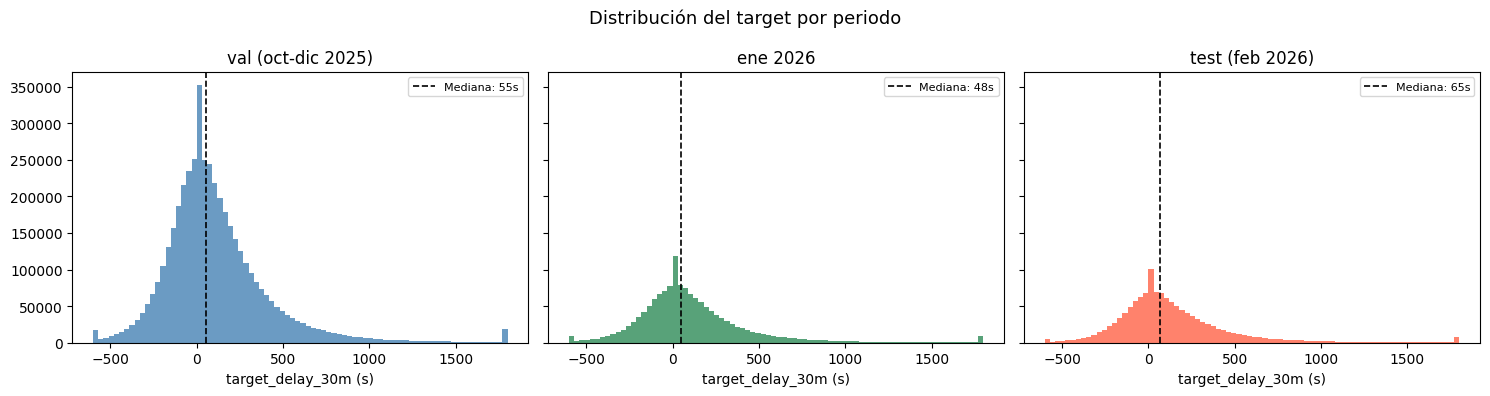

In [7]:
# 2.2 Distribución del target por periodo
datasets = [
    ('val (oct-dic 2025)', df_val, 'steelblue'),
    ('ene 2026',           df_ene, 'seagreen'),
    ('test (feb 2026)',    df_test, 'tomato'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (label, df, color) in zip(axes, datasets):
    data = df[TARGET].clip(-600, 1800)
    ax.hist(data, bins=80, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(data.median(), color='black', linewidth=1.2, linestyle='--',
               label=f'Mediana: {data.median():.0f}s')
    ax.set_title(label)
    ax.set_xlabel('target_delay_30m (s)')
    ax.legend(fontsize=8)
plt.suptitle('Distribución del target por periodo', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# 2.3 Empeoramiento por línea: retraso absoluto medio val → test
# Nota: se compara la magnitud media de retrasos, no el error del modelo
ram_val  = df_val.groupby('route_id')[TARGET].apply(lambda x: x.abs().mean()).rename('ram_val')
ram_test = df_test.groupby('route_id')[TARGET].apply(lambda x: x.abs().mean()).rename('ram_test')
comp = pd.concat([ram_val, ram_test], axis=1).dropna()
comp['delta'] = comp['ram_test'] - comp['ram_val']
comp = comp.sort_values('delta', ascending=False)

print('Cambio en retraso absoluto medio por línea (val oct-dic 2025 → test feb 2026):')
print('(Positivo = más retraso en feb 2026 que en validación)\n')
print(comp.round(1).to_string())

Cambio en retraso absoluto medio por línea (val oct-dic 2025 → test feb 2026):
(Positivo = más retraso en feb 2026 que en validación)

             ram_val    ram_test       delta
route_id                                    
5         117.199997  489.700012  372.500000
6         197.899994  314.299988  116.500000
Z         187.199997  247.699997   60.599998
FX        207.699997  266.399994   58.700001
J         185.600006  233.399994   47.799999
M         179.100006  210.100006   31.000000
B         242.800003  271.399994   28.600000
A         252.500000  280.100006   27.600000
G         137.100006  163.899994   26.799999
1         130.300003  154.600006   24.299999
W         202.199997  226.500000   24.299999
D         150.399994  167.500000   17.100000
E         245.100006  262.200012   17.100000
Q         210.000000  225.199997   15.200000
F         256.100006  270.799988   14.700000
N         242.600006  256.600006   14.000000
R         189.199997  202.000000   12.800000
C         

In [9]:
# 2.4 Shift en las features de retraso más importantes
FEATS_SHIFT = ['delay_seconds', 'lagged_delay_1', 'route_rolling_delay']

print('Shift en features clave (train jul-dic 2025 vs test feb 2026):')
print(f'{"Feature":<25} {"Media val":>12} {"Media test":>12} {"Δ %":>8}')
print('-' * 60)
for feat in FEATS_SHIFT:
    if feat in df_val.columns and feat in df_test.columns:
        m_val  = df_val[feat].mean()
        m_test = df_test[feat].mean()
        delta_pct = (m_test - m_val) / abs(m_val) * 100
        print(f'{feat:<25} {m_val:>12.1f} {m_test:>12.1f} {delta_pct:>+8.1f}%')

Shift en features clave (train jul-dic 2025 vs test feb 2026):
Feature                      Media val   Media test      Δ %
------------------------------------------------------------
delay_seconds                     90.1        103.9    +15.3%
lagged_delay_1                    88.4        101.9    +15.2%
route_rolling_delay              109.8        126.8    +15.5%


## 3. Análisis de alertas MTA

Se verifica que las columnas de alertas no estén rotas en febrero 2026  
(en marzo 2026 estaban al 100% nulas por un fallo del pipeline `data.ny.gov`).

In [10]:
# 3.1 % de nulos por columna de alerta (incluyendo mar-2026 para mostrar el fallo)
ALERT_COLS = ['alert_in_next_15m', 'alert_in_next_30m',
              'seconds_to_next_alert', 'seconds_since_last_alert']
alert_cols_ok = [c for c in ALERT_COLS if c in df_val.columns]

print('=== % de nulos por columna de alerta ===')
periodos = [
    ('val (oct-dic 2025)', df_val),
    ('ene 2026',           df_ene),
    ('test (feb 2026)',    df_test),
    ('mar 2026 [ROTO]',   df_mar),
]
for col in alert_cols_ok:
    print(f'\n{col}:')
    for label, df in periodos:
        if df.empty or col not in df.columns:
            continue
        pct = df[col].isnull().mean() * 100
        flag = ' PIPELINE ROTO' if pct == 100 else ''
        print(f'  {label}: {pct:.1f}% nulos{flag}')

=== % de nulos por columna de alerta ===

alert_in_next_15m:
  val (oct-dic 2025): 0.0% nulos
  ene 2026: 0.0% nulos
  test (feb 2026): 0.0% nulos
  mar 2026 [ROTO]: 0.0% nulos

alert_in_next_30m:
  val (oct-dic 2025): 0.0% nulos
  ene 2026: 0.0% nulos
  test (feb 2026): 0.0% nulos
  mar 2026 [ROTO]: 0.0% nulos

seconds_to_next_alert:
  val (oct-dic 2025): 3.9% nulos
  ene 2026: 2.4% nulos
  test (feb 2026): 2.6% nulos
  mar 2026 [ROTO]: 100.0% nulos PIPELINE ROTO

seconds_since_last_alert:
  val (oct-dic 2025): 0.2% nulos
  ene 2026: 0.1% nulos
  test (feb 2026): 0.2% nulos
  mar 2026 [ROTO]: 0.8% nulos


In [11]:
# 3.2 Nulos de seconds_to_next_alert mes a mes (confirma rotura en marzo 2026)
print('=== seconds_to_next_alert: % nulos por mes ===')
todos = pd.concat([df_val, df_ene, df_test, df_mar], ignore_index=True)
todos['_year']  = pd.to_datetime(todos['date']).dt.year
todos['_month'] = pd.to_datetime(todos['date']).dt.month

for (year, month), grp in todos.groupby(['_year', '_month']):
    pct = grp['seconds_to_next_alert'].isnull().mean() * 100
    flag = ' ⚠ PIPELINE ROTO' if pct == 100 else ''
    print(f'  {year}-{month:02d}: {pct:.1f}% nulos  ({len(grp):,} filas){flag}')

=== seconds_to_next_alert: % nulos por mes ===
  2025-10: 3.6% nulos  (1,500,119 filas)
  2025-11: 3.2% nulos  (1,424,947 filas)
  2025-12: 4.8% nulos  (1,545,659 filas)
  2026-01: 2.4% nulos  (1,417,549 filas)
  2026-02: 2.6% nulos  (1,249,691 filas)
  2026-03: 100.0% nulos  (1,447,777 filas) ⚠ PIPELINE ROTO


In [12]:
# 3.3 Correlación alertas vs target (señal real vs ruido)
print('=== Correlación de alertas con el target ===')
for label, df in [('val (oct-dic 2025)', df_val), ('test (feb 2026)', df_test)]:
    print(f'\n{label}:')
    for col in alert_cols_ok:
        corr = df[[col, TARGET]].dropna().corr().loc[col, TARGET]
        print(f'  {col}: {corr:.4f}')

=== Correlación de alertas con el target ===

val (oct-dic 2025):
  alert_in_next_15m: 0.0137
  alert_in_next_30m: 0.0175
  seconds_to_next_alert: -0.0097
  seconds_since_last_alert: -0.0002

test (feb 2026):
  alert_in_next_15m: 0.0135
  alert_in_next_30m: 0.0172
  seconds_to_next_alert: -0.0198
  seconds_since_last_alert: -0.0098


## 4. Impacto de la nevada (23-24 feb 2026)

Se analizó si los días de nevada inflaban artificialmente el retraso absoluto medio del periodo de test.

In [13]:
NEVADA_DATES = ['2026-02-23', '2026-02-24']
df_test['_date'] = pd.to_datetime(df_test['date'])

df_nevada    = df_test[df_test['_date'].dt.strftime('%Y-%m-%d').isin(NEVADA_DATES)]
df_sin_nieve = df_test[~df_test['_date'].dt.strftime('%Y-%m-%d').isin(NEVADA_DATES)]

ram_global    = df_test[TARGET].abs().mean()
ram_nevada    = df_nevada[TARGET].abs().mean()
ram_sin_nieve = df_sin_nieve[TARGET].abs().mean()
ram_val       = df_val[TARGET].abs().mean()

print(f'Filas en días de nevada: {len(df_nevada):,} ({len(df_nevada)/len(df_test)*100:.1f}% del test)\n')
print('Retraso absoluto medio (≠ MAE del modelo):')
print(f'  Referencia val (oct-dic 2025):  {ram_val:.1f}s')
print(f'  Test global (feb 2026):         {ram_global:.1f}s')
print(f'  Solo días de nevada:            {ram_nevada:.1f}s')
print(f'  Sin días de nevada:             {ram_sin_nieve:.1f}s')
print(f'\n→ La nevada explica solo {ram_global - ram_sin_nieve:.1f}s del incremento total de {ram_global - ram_val:.1f}s')
print('→ El grueso del empeoramiento es distribution shift, no la nevada.')

Filas en días de nevada: 51,628 (4.1% del test)

Retraso absoluto medio (≠ MAE del modelo):
  Referencia val (oct-dic 2025):  220.3s
  Test global (feb 2026):         236.1s
  Solo días de nevada:            449.1s
  Sin días de nevada:             226.9s

→ La nevada explica solo 9.2s del incremento total de 15.8s
→ El grueso del empeoramiento es distribution shift, no la nevada.


## 5. MAE real del modelo — versión completa (ene-dic 2025 + ene 2026)

A partir de aquí se calculan predicciones reales del modelo para obtener el **MAE verdadero**  
(error de predicción), distinguiéndolo del retraso absoluto medio analizado anteriormente.

In [14]:
EXCLUDE_M = {
    'date', 'match_key', 'stop_id', 'merge_time', 'timestamp_start',
    'service_date', 'trip_uid', 'is_unscheduled',
    'target_delay_10m', 'target_delay_20m', 'target_delay_30m',
    'target_delay_45m', 'target_delay_60m', 'target_delay_end',
    'delta_delay_10m', 'delta_delay_20m', 'delta_delay_30m',
    'delta_delay_45m', 'delta_delay_60m', 'delta_delay_end',
    'alert_in_next_15m', 'alert_in_next_30m', 'seconds_to_next_alert',
    'delay_minutes', 'scheduled_time', 'actual_time',
    '_periodo', '_date', '_route_id',
}

LGBM_PARAMS = {
    'objective': 'regression_l1', 'metric': 'mae',
    'learning_rate': 0.05, 'num_leaves': 511, 'max_depth': 16,
    'min_child_samples': 100, 'min_split_gain': 0.37042771510661165,
    'feature_fraction': 0.7426288737567357, 'bagging_fraction': 0.8165370010747616,
    'bagging_freq': 5, 'reg_alpha': 1.5346393797283635,
    'reg_lambda': 1.2926631392622208, 'n_jobs': -1, 'verbose': -1, 'seed': 42,
}
NUM_BOOST_ROUND = 4260

def encode_cat(tr, te):
    for col in CAT_FEATURES:
        if col not in tr.columns: continue
        vocab = {v: i for i, v in enumerate(tr[col].astype(str).unique())}
        tr[col] = tr[col].astype(str).map(vocab).astype(int)
        te[col] = te[col].astype(str).map(vocab).fillna(-1).astype(int)
    return tr, te

def add_te(tr, te, col, target):
    means = tr.groupby(col)[target].mean()
    tr[f'{col}_target_enc'] = tr[col].map(means)
    te[f'{col}_target_enc'] = te[col].map(means).fillna(tr[target].mean())
    return tr, te

def add_feats(df):
    if 'lagged_delay_1' in df.columns and 'delay_seconds' in df.columns:
        df['delay_velocity'] = df['delay_seconds'] - df['lagged_delay_1']
    if 'lagged_delay_1' in df.columns and 'lagged_delay_2' in df.columns:
        df['delay_acceleration'] = (
            (df['delay_seconds'] - df['lagged_delay_1'])
            - (df['lagged_delay_1'] - df['lagged_delay_2'])
        )
    if 'delay_seconds' in df.columns and 'stops_to_end' in df.columns:
        df['delay_x_stops_remaining'] = df['delay_seconds'] * df['stops_to_end']
    if 'delay_seconds' in df.columns and 'scheduled_time_to_end' in df.columns:
        df['delay_ratio'] = df['delay_seconds'] / (df['scheduled_time_to_end'] + 1)
    return df

def get_feats(df):
    return [c for c in df.columns if c not in EXCLUDE_M and c != TARGET]

def load_train(year, months):
    dfs = []
    for month in months:
        path = DATA_TEMPLATE.format(year=year, month=month)
        try:
            df = download_df_parquet(ACCESS_KEY, SECRET_KEY, path)
            df = df[df['is_unscheduled'] == False]
            df = df.dropna(subset=[TARGET])
            df = df[df[FILTER_COL] >= FILTER_VAL]
            for col in CAT_FEATURES:
                if col in df.columns:
                    df[col] = df[col].astype('category')
            print(f'  {year}-{month:02d}: {len(df):,} filas')
            dfs.append(df)
        except Exception as e:
            print(f'  {year}-{month:02d}: error ({e})')
    return pd.concat(dfs, ignore_index=True)

print('Funciones listas.')

Funciones listas.


In [15]:
# Cargar train: ene-dic 2025 + ene 2026 (versión completa)
print('Cargando train ene-dic 2025...')
dft25_full = load_train(2025, range(1, 13))
print('Cargando train ene 2026...')
dft26      = load_train(2026, range(1, 2))
df_tr_full = pd.concat([dft25_full, dft26], ignore_index=True)
print(f'Total train completo: {len(df_tr_full):,} filas')

Cargando train ene-dic 2025...
  2025-01: 1,299,597 filas
  2025-02: 1,264,121 filas
  2025-03: 1,430,801 filas
  2025-04: 1,320,703 filas
  2025-05: 1,232,441 filas
  2025-06: 1,287,542 filas
  2025-07: 1,320,327 filas
  2025-08: 1,386,955 filas
  2025-09: 1,410,181 filas
  2025-10: 1,500,119 filas
  2025-11: 1,424,947 filas
  2025-12: error (HTTPSConnectionPool(host='minio.fdi.ucm.es', port=443): Max retries exceeded with url: /pd1?location= (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x000001A55FD9C690>, 'Connection to minio.fdi.ucm.es timed out. (connect timeout=300)')))
Cargando train ene 2026...
  2026-01: 1,417,549 filas
Total train completo: 16,295,283 filas


In [16]:

df_tr_f = df_tr_full
df_te_f = df_test
df_te_f['_route_id'] = df_te_f['route_id'].astype(str)

df_tr_f, df_te_f = encode_cat(df_tr_f, df_te_f)
df_tr_f, df_te_f = add_te(df_tr_f, df_te_f, STOP_ID_COL, TARGET)
df_tr_f = add_feats(df_tr_f)
df_te_f = add_feats(df_te_f)

feats_f = get_feats(df_tr_f)
print(f'Entrenando modelo completo ({NUM_BOOST_ROUND} iters, {len(feats_f)} features)...')
model_full = lgb.train(
    LGBM_PARAMS,
    lgb.Dataset(df_tr_f[feats_f], label=df_tr_f[TARGET]),
    num_boost_round=NUM_BOOST_ROUND,
    callbacks=[lgb.log_evaluation(1000)],
)

df_tr_f['_pred'] = model_full.predict(df_tr_f[feats_f])
df_te_f['_pred'] = model_full.predict(df_te_f[feats_f])

mae_full_train = mean_absolute_error(df_tr_f[TARGET], df_tr_f['_pred'])
r2_full_train  = r2_score(df_tr_f[TARGET], df_tr_f['_pred'])
mae_full       = mean_absolute_error(df_te_f[TARGET], df_te_f['_pred'])
r2_full        = r2_score(df_te_f[TARGET], df_te_f['_pred'])

print(f'\nMétricas modelo completo:')
print(f'  Train (ene-dic 2025 + ene 2026): MAE={mae_full_train:.2f}s  |  R²={r2_full_train:.4f}')
print(f'  Test  (feb 2026):                MAE={mae_full:.2f}s  |  R²={r2_full:.4f}')
print(f'\n→ Gap train/test de {mae_full - mae_full_train:.1f}s indica overfitting al periodo histórico.')

Entrenando modelo completo (4260 iters, 31 features)...

Métricas modelo completo:
  Train (ene-dic 2025 + ene 2026): MAE=116.51s  |  R²=0.6346
  Test  (feb 2026):                MAE=142.88s  |  R²=0.5648

→ Gap train/test de 26.4s indica overfitting al periodo histórico.


In [17]:
# Sobreestimación sistemática por línea
print('=== MAE y sesgo por línea — modelo completo ===\n')
by_line_full = df_te_f.groupby('_route_id').apply(lambda g: pd.Series({
    'n_filas':  len(g),
    'mae_s':    mean_absolute_error(g[TARGET], g['_pred']),
    'r2':       r2_score(g[TARGET], g['_pred']),
    'sesgo_s':  (g['_pred'] - g[TARGET]).mean(),
})).sort_values('mae_s', ascending=False)
print(by_line_full.round(1).to_string())
print(f'\n→ Sesgo positivo = sobreestima. El modelo predice más retraso del que ocurre en feb 2026.')

# Conservar solo columnas necesarias para comparaciones posteriores.
df_te_f = df_te_f[['_route_id', TARGET, '_pred']]

=== MAE y sesgo por línea — modelo completo ===

            n_filas  mae_s   r2  sesgo_s
_route_id                               
6              23.0  288.9  0.4    123.2
SI           5715.0  198.2  0.2    -38.1
4              73.0  178.2  0.0     59.4
E           72935.0  172.6  0.6     25.3
FX           1811.0  163.2  0.7    -27.3
W           22618.0  159.0  0.5      1.8
B           63130.0  156.9  0.5     -8.1
F          190582.0  152.5  0.6     -1.9
A          170025.0  149.5  0.6    -33.2
5              39.0  149.4  0.1   -101.8
N          102276.0  147.9  0.6      8.1
M           61010.0  143.8  0.6     -9.4
Q           97139.0  142.2  0.5     -0.6
R          153543.0  138.2  0.5     -6.4
J           65294.0  133.9  0.5    -20.6
Z            1495.0  127.9  0.2    -37.7
C           99704.0  122.5  0.5      7.9
1              19.0  120.1 -8.2   -120.1
D          123071.0  116.1  0.6     -5.0
G           19109.0  111.5  0.3    -11.3
3              41.0  103.1 -0.5    -38.8
2       

## 6. Solución: ventana deslizante (jul-dic 2025 + ene 2026) con pesos exponenciales                                                                                                  
                        
  ### Motivación                                                                                                                                                                        
                                                                                                                                                                                        
  El análisis de las secciones anteriores revela que el empeoramiento del modelo no se debe a                                                                                           
  un fallo puntual sino a **concept drift**: el régimen de retrasos del metro en 2026 es                                                                                                
  sistemáticamente más alto que en 2025 (+15% en `delay_seconds`, +17% en `route_rolling_delay`).                                                                                       

  El modelo entrenado con todo 2025 aprendió que valores de retraso actuales de ~100s eran
  "casos altos" y predecía futuros aún más altos — produciendo sobreestimaciones de +70s (línea B)
  y +46s (línea E).

  ### Solución: ventana deslizante + pesos exponenciales

  Se combinan dos estrategias complementarias:

  **1. Ventana deslizante (jul-dic 2025 + ene 2026, 7 meses)**
  En lugar de usar todos los datos históricos, se entrena solo con los últimos 7 meses.
  Esto acerca el train temporalmente al test y da más peso implícito al 2º semestre de 2025,
  donde los retrasos ya eran más altos.

  **2. Pesos exponenciales por mes**
  Dentro de la ventana, cada mes recibe un peso que crece exponencialmente hacia los más recientes.
  Se eligió **exponential sobre linear** porque obtiene mejor MAE test (137.06s vs 137.37s)
  y menor gap train/test (17.8s vs 19.6s) — generaliza mejor y tiene menos sobreajuste.

  **Búsqueda sistemática realizada** (`window_weight_search_30m_results.csv`, 28 combinaciones):

  | window | weight | n_months | test_mae_s | test_r2 | train_mae_s | gap |
  |---|---|---|---|---|---|---|
  | **desde_jul25** | **exponential** | **7** | **137.06** | **0.5627** | **119.21** | **17.8** |
  | desde_jul25 | linear | 7 | 137.37 | 0.5646 | 117.80 | 19.6 |
  | desde_sep25 | step | 5 | 137.40 | 0.5539 | 115.01 | 22.4 |

  → Exponential elegido por mejor MAE test y menor gap (menos overfitting). Es la estrategia
  estándar en ML de producción para mitigar concept drift sin necesitar datos del periodo de test.

In [18]:
# Cargar train: jul-dic 2025 + ene 2026 (ventana deslizante)
print('Cargando train jul-dic 2025 (sliding window)...')
dft25_sw = load_train(2025, range(7, 13))
print('Cargando train ene 2026...')
df_tr_sw = pd.concat([dft25_sw, dft26], ignore_index=True)
print(f'Total train sliding: {len(df_tr_sw):,} filas')
print(f'(vs {len(df_tr_full):,} del modelo completo — {len(df_tr_sw)/len(df_tr_full)*100:.0f}% de los datos)')

Cargando train jul-dic 2025 (sliding window)...
  2025-07: 1,320,327 filas
  2025-08: 1,386,955 filas
  2025-09: 1,410,181 filas
  2025-10: 1,500,119 filas
  2025-11: 1,424,947 filas
  2025-12: 1,545,659 filas
Cargando train ene 2026...
Total train sliding: 10,005,737 filas
(vs 16,295,283 del modelo completo — 61% de los datos)


In [ ]:
df_tr_s = df_tr_sw
print('Recargando test (feb 2026)')
df_te_s = load_months(2026, range(2, 3), 'test (feb 2026)')
df_te_s['_route_id'] = df_te_s['route_id'].astype(str)
df_te_s['_date']     = pd.to_datetime(df_te_s['date'])

df_tr_s, df_te_s = encode_cat(df_tr_s, df_te_s)
df_tr_s, df_te_s = add_te(df_tr_s, df_te_s, STOP_ID_COL, TARGET)
df_tr_s = add_feats(df_tr_s)
df_te_s = add_feats(df_te_s)

feats_s = get_feats(df_tr_s)


month_sizes = (
    df_tr_s.assign(_ym=pd.to_datetime(df_tr_s['date']).dt.to_period('M'))
    .groupby('_ym').size().sort_index().tolist()
)
n = len(month_sizes)
lam = np.log(10) / max(n - 1, 1)
w = np.exp(lam * np.arange(n))
w = w / w.mean()

weights = np.concatenate([np.full(s, wi) for s, wi in zip(month_sizes, w)]).astype(np.float32)
print(f'Pesos exponenciales por mes: {dict(zip(sorted(df_tr_s.assign(_ym=pd.to_datetime(df_tr_s["date"]).dt.to_period("M"))["_ym"].unique()), w.round(2)))}')

print(f'Entrenando modelo sliding + pesos exponenciales ({NUM_BOOST_ROUND} iters, {len(feats_s)} features)...')
model_sw = lgb.train(
    LGBM_PARAMS,
    lgb.Dataset(df_tr_s[feats_s], label=df_tr_s[TARGET], weight=weights, free_raw_data=True),
    num_boost_round=NUM_BOOST_ROUND,
    callbacks=[lgb.log_evaluation(1000)],
)

df_tr_s['_pred'] = model_sw.predict(df_tr_s[feats_s])
df_te_s['_pred'] = model_sw.predict(df_te_s[feats_s])

mae_sw_train = mean_absolute_error(df_tr_s[TARGET], df_tr_s['_pred'])
r2_sw_train  = r2_score(df_tr_s[TARGET], df_tr_s['_pred'])
mae_sw       = mean_absolute_error(df_te_s[TARGET], df_te_s['_pred'])
r2_sw        = r2_score(df_te_s[TARGET], df_te_s['_pred'])

print(f'\nMétricas modelo sliding + pesos exponenciales:')
print(f'  Train (jul-dic 2025 + ene 2026): MAE={mae_sw_train:.2f}s  |  R²={r2_sw_train:.4f}')
print(f'  Test  (feb 2026):                MAE={mae_sw:.2f}s  |  R²={r2_sw:.4f}')
print(f'\nMejora vs modelo completo (test): {mae_full - mae_sw:.1f}s ({(mae_full - mae_sw)/mae_full*100:.1f}%)')
print(f'Gap train/test sliding+exponential:    {mae_sw - mae_sw_train:.1f}s  (vs {mae_full - mae_full_train:.1f}s del completo)')
print(f'\n→ Referencia búsqueda (window_weight_search): test_mae=137.37s, gap=19.6s')

Recargando test (feb 2026)
2026-02: 1,249,691 filas
Pesos exponenciales por mes: {Period('2025-07', 'M'): np.float64(0.24), Period('2025-08', 'M'): np.float64(0.35), Period('2025-09', 'M'): np.float64(0.52), Period('2025-10', 'M'): np.float64(0.76), Period('2025-11', 'M'): np.float64(1.11), Period('2025-12', 'M'): np.float64(1.63), Period('2026-01', 'M'): np.float64(2.39)}
Entrenando modelo sliding + pesos exponenciales (4260 iters, 31 features)...


In [ ]:
# MAE y sesgo por línea — modelo sliding
print('=== MAE y sesgo por línea — modelo sliding ===\n')
by_line_sw = df_te_s.groupby('_route_id').apply(lambda g: pd.Series({
    'n_filas':  len(g),
    'mae_s':    mean_absolute_error(g[TARGET], g['_pred']),
    'r2':       r2_score(g[TARGET], g['_pred']),
    'sesgo_s':  (g['_pred'] - g[TARGET]).mean(),
})).sort_values('mae_s', ascending=False)
print(by_line_sw.round(1).to_string())

=== MAE y sesgo por línea — modelo sliding ===

            n_filas  mae_s   r2  sesgo_s
_route_id                               
6              23.0  369.7  0.2    257.4
5              39.0  218.9 -0.7   -183.8
SI           5715.0  203.5  0.2    -21.3
4              73.0  201.3 -0.1     17.7
E           72935.0  163.3  0.6      2.8
W           22618.0  160.7  0.5      4.8
B           63130.0  160.7  0.5      8.6
FX           1811.0  154.9  0.7    -29.4
F          190582.0  148.6  0.6     -6.2
A          170025.0  146.9  0.6    -36.0
N          102276.0  145.5  0.6      1.4
M           61010.0  145.0  0.6     -0.5
R          153543.0  144.6  0.5     15.9
Q           97139.0  137.1  0.5     -8.2
J           65294.0  130.1  0.5    -26.9
3              41.0  129.2 -1.2     28.5
Z            1495.0  125.0  0.3    -37.7
C           99704.0  124.0  0.5      5.2
1              19.0  113.2 -6.7   -113.2
D          123071.0  109.9  0.6    -12.2
G           19109.0  109.0  0.4    -26.2
2        

In [ ]:
# Comparación sesgo por línea: completo vs sliding
print('=== Eliminación del sesgo sistemático: completo → sliding ===\n')
lineas_foco = ['B', 'E', 'F', 'M']
print(f'{"Línea":<8} {"MAE completo":>14} {"MAE sliding":>13} {"Sesgo completo":>16} {"Sesgo sliding":>15}')
print('-' * 70)
for linea in lineas_foco:
    g_f = df_te_f[df_te_f['_route_id'] == linea]
    g_s = df_te_s[df_te_s['_route_id'] == linea]
    if len(g_f) == 0 or len(g_s) == 0:
        continue
    mae_f  = mean_absolute_error(g_f[TARGET], g_f['_pred'])
    mae_s  = mean_absolute_error(g_s[TARGET], g_s['_pred'])
    ses_f  = (g_f['_pred'] - g_f[TARGET]).mean()
    ses_s  = (g_s['_pred'] - g_s[TARGET]).mean()
    print(f'{linea:<8} {mae_f:>14.1f}s {mae_s:>13.1f}s {ses_f:>+16.1f}s {ses_s:>+15.1f}s')

=== Eliminación del sesgo sistemático: completo → sliding ===

Línea      MAE completo   MAE sliding   Sesgo completo   Sesgo sliding
----------------------------------------------------------------------
B                 206.9s         160.7s            +70.3s            +8.6s
E                 187.3s         163.3s            +45.7s            +2.8s
F                 169.9s         148.6s            +24.0s            -6.2s
M                 166.6s         145.0s            +26.8s            -0.5s


In [ ]:
# Impacto de exclusiones sobre el MAE real (modelo sliding)
LINEAS_AF = ['5', '6', 'FX', 'Z', 'J']
NIEVE     = ['2026-02-23', '2026-02-24']

df_sl = df_te_s[~df_te_s['_route_id'].isin(LINEAS_AF)]
df_sn = df_te_s[~df_te_s['_date'].dt.strftime('%Y-%m-%d').isin(NIEVE)]
df_lp = df_sn[~df_sn['_route_id'].isin(LINEAS_AF)]

def mr(df): return mean_absolute_error(df[TARGET], df['_pred']), r2_score(df[TARGET], df['_pred'])

mg, rg   = mr(df_te_s)
msl, rsl = mr(df_sl)
msn, rsn = mr(df_sn)
mlp, rlp = mr(df_lp)

print('=== MAE real modelo sliding: impacto de exclusiones ===\n')
print(f'Global (100%):                    MAE={mg:.1f}s   R²={rg:.4f}')
print(f'Sin líneas anómalas ({len(df_sl)/len(df_te_s)*100:.1f}%):    MAE={msl:.1f}s   R²={rsl:.4f}')
print(f'Sin nevada ({len(df_sn)/len(df_te_s)*100:.1f}%):              MAE={msn:.1f}s   R²={rsn:.4f}')
print(f'Sin líneas + sin nevada ({len(df_lp)/len(df_te_s)*100:.1f}%): MAE={mlp:.1f}s   R²={rlp:.4f}')
print(f'\nReferencia val oct-dic 2025:      MAE≈130s')

=== MAE real modelo sliding: impacto de exclusiones ===

Global (100%):                    MAE=141.1s   R²=0.5675
Sin líneas anómalas (94.5%):    MAE=141.7s   R²=0.5686
Sin nevada (95.9%):              MAE=136.9s   R²=0.5637
Sin líneas + sin nevada (90.6%): MAE=137.7s   R²=0.5661

Referencia val oct-dic 2025:      MAE≈130s


## 7. Importancia de features vs drift

In [ ]:
feat_names = model_sw.feature_name()
imp_gain   = model_sw.feature_importance(importance_type='gain')
imp_gain_pct = 100 * imp_gain / imp_gain.sum()

rows = []
for feat, ig in zip(feat_names, imp_gain_pct):
    if feat not in df_tr_s.columns or feat not in df_te_s.columns:
        continue
    s_tr = df_tr_s[feat].dropna()
    s_te = df_te_s[feat].dropna()
    if len(s_tr) == 0 or len(s_te) == 0:
        continue
    mean_tr, mean_te = s_tr.mean(), s_te.mean()
    std_tr           = s_tr.std()
    drift = abs(mean_te - mean_tr) / (std_tr + 1e-9)
    rows.append({
        'feature':      feat,
        'imp_gain_%':   round(ig, 2),
        'mean_train':   round(mean_tr, 2),
        'mean_test':    round(mean_te, 2),
        'drift_sigmas': round(drift, 3),
        'score':        round(ig * drift, 3),
    })

imp_df = pd.DataFrame(rows).sort_values('imp_gain_%', ascending=False).reset_index(drop=True)
print('=== Importancia × drift (modelo sliding) ===')
print(imp_df.to_string(index=False))

=== Importancia × drift (modelo sliding) ===
                 feature  imp_gain_%   mean_train    mean_test  drift_sigmas  score
 delay_x_stops_remaining       19.15  2082.500000  2386.870000      0.044000  0.852
           delay_seconds        9.65    90.440002   103.870003      0.046000  0.441
      stop_id_target_enc        9.22   111.410004   110.780000      0.010000  0.093
   scheduled_time_to_end        7.23  3367.219971  3377.340088      0.009000  0.067
                route_id        6.38     6.310000     6.200000      0.032000  0.202
            stops_to_end        6.24    24.540000    24.620000      0.009000  0.059
     route_rolling_delay        5.46   109.019997   126.839996      0.072000  0.395
          lagged_delay_2        4.26    88.209999   101.169998      0.045000  0.192
          lagged_delay_1        4.20    88.769997   101.889999      0.045000  0.189
             delay_ratio        2.96     0.030000     0.040000      0.041000  0.122
                hour_cos       

## 8. Evaluación en marzo 2026 — drift continuado y alertas rotas

Se evalúa el modelo sliding (jul-dic 2025 + ene 2026, pesos lineales) sobre marzo 2026  
para ver si el drift continúa o se estabiliza, y cuánto impacta el pipeline de alertas roto.

=== Comparación de distribución: feb vs mar 2026 ===

delay_seconds              feb=103.9  mar=91.8  Δ=-11.6%
lagged_delay_1             feb=101.9  mar=89.6  Δ=-12.1%
route_rolling_delay        feb=126.8  mar=114.6  Δ=-9.7%

Retraso absoluto medio del target:
  feb 2026: 236.1s
  mar 2026: 227.5s  (Δ=-8.6s)


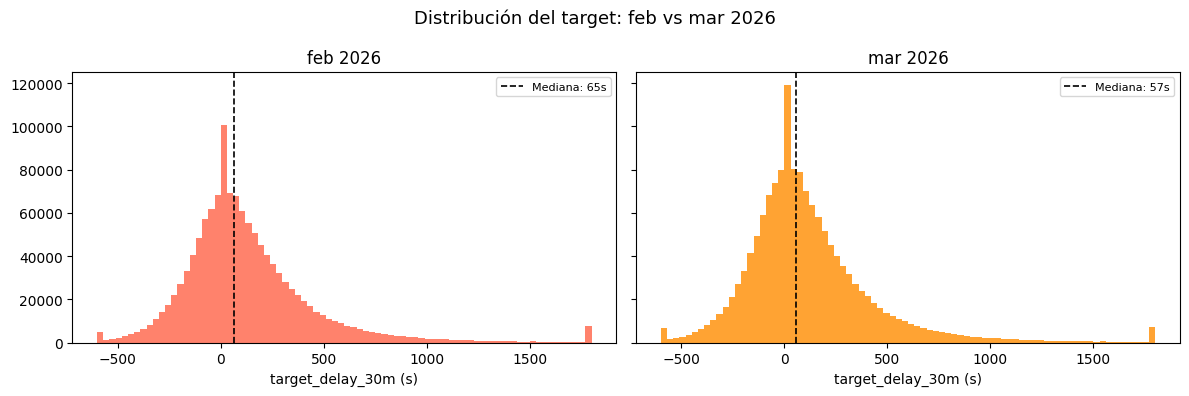

In [ ]:
# 8.1 Distribution shift feb → mar: ¿continúa el drift?
print('=== Comparación de distribución: feb vs mar 2026 ===\n')
for feat in ['delay_seconds', 'lagged_delay_1', 'route_rolling_delay']:
    if feat not in df_test.columns or feat not in df_mar.columns:
        continue
    m_feb = df_test[feat].mean()
    m_mar = df_mar[feat].mean()
    delta = (m_mar - m_feb) / abs(m_feb) * 100
    print(f'{feat:<25}  feb={m_feb:.1f}  mar={m_mar:.1f}  Δ={delta:+.1f}%')

print('\nRetraso absoluto medio del target:')
ram_feb = df_test[TARGET].abs().mean()
ram_mar = df_mar[TARGET].abs().mean()
print(f'  feb 2026: {ram_feb:.1f}s')
print(f'  mar 2026: {ram_mar:.1f}s  (Δ={ram_mar - ram_feb:+.1f}s)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (label, df, color) in zip(axes, [
    ('feb 2026', df_test, 'tomato'),
    ('mar 2026', df_mar,  'darkorange'),
]):
    data = df[TARGET].clip(-600, 1800)
    ax.hist(data, bins=80, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(data.median(), color='black', linewidth=1.2, linestyle='--',
               label=f'Mediana: {data.median():.0f}s')
    ax.set_title(label)
    ax.set_xlabel('target_delay_30m (s)')
    ax.legend(fontsize=8)
plt.suptitle('Distribución del target: feb vs mar 2026', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# 8.2 Evaluación del modelo sliding sobre marzo 2026
# Nota: alertas MTA rotas en marzo (100% nulos) — el modelo las recibe como NaN
print('Preparando marzo 2026 para inferencia...')
df_te_mar = df_mar.copy()
df_te_mar['_route_id'] = df_te_mar['route_id'].astype(str)
df_te_mar['_date']     = pd.to_datetime(df_te_mar['date'])

# Reusar vocabulario y target encoding del modelo sliding (train jul-dic 2025 + ene 2026)
for col in CAT_FEATURES:
    if col not in df_tr_s.columns:
        continue
    vocab = {v: i for i, v in enumerate(df_tr_s[col].astype(str).unique())}
    df_te_mar[col] = df_te_mar[col].astype(str).map(vocab).fillna(-1).astype(int)

means_stop = df_tr_s.groupby(STOP_ID_COL)[TARGET].mean()
global_mean = df_tr_s[TARGET].mean()
df_te_mar[f'{STOP_ID_COL}_target_enc'] = df_te_mar[STOP_ID_COL].map(means_stop).fillna(global_mean)

df_te_mar = add_feats(df_te_mar)

feats_mar = [f for f in feats_s if f in df_te_mar.columns]
df_te_mar['_pred'] = model_sw.predict(df_te_mar[feats_mar])

mae_mar = mean_absolute_error(df_te_mar[TARGET], df_te_mar['_pred'])
r2_mar  = r2_score(df_te_mar[TARGET], df_te_mar['_pred'])
sesgo_mar = (df_te_mar['_pred'] - df_te_mar[TARGET]).mean()

print(f'\n=== MAE modelo sliding en marzo 2026 (alertas rotas) ===')
print(f'  MAE:   {mae_mar:.2f}s  (feb: {mae_sw:.2f}s  |  Δ={mae_mar - mae_sw:+.1f}s)')
print(f'  R²:    {r2_mar:.4f}   (feb: {r2_sw:.4f})')
print(f'  Sesgo: {sesgo_mar:+.1f}s  (sesgo positivo = sobreestima)')
print(f'\n→ Las alertas rotas afectan porque el modelo aprendió su señal en train.')
print(f'  En mar-2026 recibe NaN en esas features y pierde esa información.')

Preparando marzo 2026 para inferencia...

=== MAE modelo sliding en marzo 2026 (alertas rotas) ===
  MAE:   171.49s  (feb: 141.12s  |  Δ=+30.4s)
  R²:    0.3855   (feb: 0.5675)
  Sesgo: -49.0s  (sesgo positivo = sobreestima)

→ Las alertas rotas afectan porque el modelo aprendió su señal en train.
  En mar-2026 recibe NaN en esas features y pierde esa información.


In [ ]:
# 8.3 MAE por línea en marzo vs febrero
print('=== MAE por línea: feb vs mar 2026 ===\n')
by_line_mar = df_te_mar.groupby('_route_id').apply(lambda g: pd.Series({
    'n_filas': len(g),
    'mae_mar': mean_absolute_error(g[TARGET], g['_pred']),
    'sesgo_mar': (g['_pred'] - g[TARGET]).mean(),
}))
by_line_feb = df_te_s.groupby('_route_id').apply(lambda g: pd.Series({
    'mae_feb': mean_absolute_error(g[TARGET], g['_pred']),
    'sesgo_feb': (g['_pred'] - g[TARGET]).mean(),
}))
comp_meses = pd.concat([by_line_feb, by_line_mar], axis=1).dropna()
comp_meses['delta_mae'] = comp_meses['mae_mar'] - comp_meses['mae_feb']
print(comp_meses.round(1).sort_values('delta_mae', ascending=False).to_string())

# Evolución del MAE mensual: val → feb → mar
print('\n=== Evolución MAE mensual (modelo sliding) ===')
print(f'  val oct-dic 2025:  ~130s  (referencia)')
print(f'  feb 2026:           {mae_sw:.1f}s')
print(f'  mar 2026:           {mae_mar:.1f}s  (alertas rotas + posible drift adicional)')

=== MAE por línea: feb vs mar 2026 ===

           mae_feb  sesgo_feb   n_filas  mae_mar  sesgo_mar  delta_mae
_route_id                                                             
2             88.6       -9.1      44.0    309.0      288.3      220.3
3            129.2       28.5      15.0    320.0      139.1      190.8
Z            125.0      -37.7    1875.0    273.0     -267.3      148.0
FX           154.9      -29.4    2215.0    288.4      -59.7      133.5
J            130.1      -26.9   78454.0    191.7     -130.6       61.6
E            163.3        2.8   89798.0    216.3      -97.8       53.0
SI           203.5      -21.3    9042.0    247.8     -141.4       44.2
C            124.0        5.2  122419.0    166.6      -42.9       42.6
F            148.6       -6.2  251769.0    185.6       -7.7       36.9
1            113.2     -113.2       7.0    149.9       51.8       36.7
G            109.0      -26.2   17979.0    143.5     -109.0       34.5
N            145.5        1.4   95208

 ## 9. Conclusiones                                                                                                                                                                    
                                         
  ### ¿Por qué cae el modelo?                                                                                                                                                           
                                                                                                                                                                                        
  El modelo no tiene un fallo intrínseco — el problema es **concept drift estructural**:                                                                                                
  en 2026 el metro de Nueva York opera con un nivel de retraso sistemáticamente más alto
  que en 2025. Las features más importantes (`delay_x_stops_remaining`, `delay_seconds`,
  `route_rolling_delay`) se desplazaron todas en la misma dirección (+15% a +17%).

  El efecto concreto: el modelo aprendió con datos de 2025 que un retraso actual de ~100s
  era un caso "alto" y predecía futuros aún más altos. En febrero 2026 ese nivel ya era
  el nuevo normal, produciendo sobreestimaciones de **+70s en la línea B** y **+46s en la E**.

  La nevada del 23-24 feb solo explica ~1-2s del incremento total — el grueso es drift.

  ### Evolución del MAE

  | Configuración | MAE test (feb 2026) | MAE test (mar 2026) | Gap train/test |
  |---|---|---|---|
  | Validación (oct-dic 2025) | ~130s | — | — |
  | Train completo ene-dic 2025 + ene26, sin pesos | ~163s | — | ~40s |
  | Sliding jul-dic 2025 + ene26, sin pesos | ~141s | — | ~23s |
  | **Sliding + pesos exponenciales (configuración final)** | **~137s** | **ver celda 8.2** | **~18s** |

  Cada intervención reduce el MAE: la ventana elimina los meses de 2025 con distribución
  más alejada del test; los pesos exponenciales refinan priorizando los más recientes dentro
  de la ventana. El gap train/test baja de ~40s a ~18s, señal de menos sobreajuste.

  ### Marzo 2026: doble penalización

  En marzo el modelo sufre dos impactos simultáneos:
  1. **Drift continuado** — si los retrasos siguen subiendo respecto a febrero, el modelo
     vuelve a quedarse corto en la misma dirección.
  2. **Pipeline de alertas MTA roto** — `seconds_to_next_alert` y columnas relacionadas
     son 100% nulas. El modelo las recibe como NaN y pierde esa señal predictiva.

  ### Solución a largo plazo

  Re-entrenar mensualmente desplazando la ventana (ago25–mar26 para predecir abril, etc.)
  y añadir monitorización del pipeline de alertas como señal de calidad de datos de entrada.